# Fine-tuning Cellpose-SAM

Same task and same data as `01_training_instance_segmentation.ipynb`. There we trained a U-Net
from scratch. Here we start from Cellpose-SAM, which already is trained on a cell or nucleus looks like, and
only finetune it towards our nuclei-from-actin task. That usually needs far fewer images.

Run `01_training_instance_segmentation.ipynb` up to the end of section 2 first (or
`python organize_data.py`): this notebook uses the same `dataset/` split.

Kernel: the Cellpose kernel on Research Cloud, `nlbi26-day3-cellpose` on your own laptop.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.io import imread

from cellpose import models, train, metrics, io

io.logger_setup()

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /home/mpaul2/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.11.15 
torch version:  	2.12.1+cu130
2026-09-17 23:21:17,409 [io INFO] WRITING LOG OUTPUT TO /home/mpaul2/.cellpose/run.log
2026-09-17 23:21:17,409 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.11.15 
torch version:  	2.12.1+cu130


(<Logger cellpose (DEBUG)>, PosixPath('/home/mpaul2/.cellpose/run.log'))

In [10]:
DATASET = Path('dataset')

def load(split):
    names = sorted(p.name for p in (DATASET / split / 'images').glob('*.tif'))
    images = [imread(DATASET / split / 'images' / n) for n in names]
    labels = [imread(DATASET / split / 'labels' / n) for n in names]
    return names, images, labels

train_names, train_images, train_labels = load('train')
val_names, val_images, val_labels = load('val')
test_names, test_images, test_labels = load('test')

print(len(train_images), 'train,', len(val_images), 'val,', len(test_images), 'test')

78 train, 20 test


## 1. Cellpose out of the box

Before fine-tuning, see what the pretrained model already does. Cellpose-SAM needs no
`model_type`, no `channels` and no `diameter` — it works those out itself.

In [11]:
pretrained = models.CellposeModel(gpu=True)

masks_before, _, _ = pretrained.eval(test_images, batch_size=8)

print('found', [m.max() for m in masks_before[:5]], '...')
print('labels', [l.max() for l in test_labels[:5]], '...')

2026-09-17 23:21:27,225 [core INFO] ** TORCH CUDA version installed and working. **
2026-09-17 23:21:27,226 [core INFO] >>>> using GPU (CUDA)
2026-09-17 23:21:27,227 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam_v2" to /home/mpaul2/.cellpose/models/cpsam_v2



100%|██████████| 1.15G/1.15G [00:14<00:00, 82.6MB/s]   


2026-09-17 23:21:44,420 [models INFO] >>>> loading model /home/mpaul2/.cellpose/models/cpsam_v2
2026-09-17 23:21:44,987 [utils INFO] 0%|          | 0/20 [00:00<?, ?it/s]


/opt/AI_tools_pixi/cellpose/.pixi/envs/default/lib/python3.11/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


2026-09-17 23:21:58,612 [utils INFO] 100%|##########| 20/20 [00:13<00:00,  1.47it/s]
found [np.uint16(135), np.uint16(138), np.uint16(122), np.uint16(4), np.uint16(35)] ...
labels [np.uint16(137), np.uint16(135), np.uint16(107), np.uint16(2), np.uint16(35)] ...


Score it. `average_precision` gives us TP, FP and FN per image at each IoU threshold, and
precision, recall and F1 follow from those three — the same numbers as in `01`.

In [12]:
def score(masks, threshold=0.5):
    ap, tp, fp, fn = metrics.average_precision(test_labels, masks, threshold=[threshold])
    tp, fp, fn = tp[:, 0], fp[:, 0], fn[:, 0]

    # np.maximum(..., 1) only kicks in when a count is 0, and keeps the division safe
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1)

    return pd.Series({
        'TP': tp.mean(), 'FP': fp.mean(), 'FN': fn.mean(),
        'precision': precision.mean(), 'recall': recall.mean(), 'F1': f1.mean(),
    })

score(masks_before).round(2)

TP             2.300000
FP           103.000000
FN            95.199997
precision      0.020000
recall         0.020000
F1             0.020000
dtype: float32

## 2. Fine-tune it

One call. The settings below are the ones the Cellpose docs recommend for fine-tuning;
the only one we lowered is `n_epochs`, so it finishes inside the session.

In [15]:
Path('cellpose_output').mkdir(exist_ok=True)
model = models.CellposeModel(gpu=True)

model_path, train_losses, val_losses = train.train_seg(
    model.net,
    train_data=train_images,
    train_labels=train_labels,
    test_data=val_images,    # Cellpose calls it test, it is our validation set
    test_labels=val_labels,
    n_epochs=20,             # the docs suggest 100; 20 is enough to see the effect
    learning_rate=1e-5,
    weight_decay=0.1,
    batch_size=1,
    save_path='cellpose_output',
    model_name='nuclei_from_phalloidin',
)

print('saved to', model_path)

2026-09-17 23:22:57,115 [core INFO] ** TORCH CUDA version installed and working. **
2026-09-17 23:22:57,115 [core INFO] >>>> using GPU (CUDA)
2026-09-17 23:22:58,740 [models INFO] >>>> loading model /home/mpaul2/.cellpose/models/cpsam_v2
2026-09-17 23:22:59,112 [train INFO] >>> converting bfloat16 network to float32 for training
2026-09-17 23:22:59,118 [dynamics INFO] computing flows for labels


100%|██████████| 78/78 [00:02<00:00, 34.09it/s]

2026-09-17 23:23:01,455 [dynamics INFO] computing flows for labels



100%|██████████| 20/20 [00:00<00:00, 36.85it/s]

2026-09-17 23:23:02,011 [train INFO] >>> computing diameters



100%|██████████| 20/20 [00:00<00:00, 864.54it/s]

2026-09-17 23:23:02,127 [train INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-09-17 23:23:02,671 [train INFO] >>> n_epochs=20, n_train=78, n_test=20, bsize=256, batch_size=1, nimg_per_epoch=78
2026-09-17 23:23:02,671 [train INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-09-17 23:23:02,673 [train INFO] >>> saving model to cellpose_output/models/nuclei_from_phalloidin
2026-09-17 23:23:22,243 [train INFO] 0, train_loss=6.2226, test_loss=5.6097, LR=0.000000, time 19.57s
2026-09-17 23:24:53,307 [train INFO] 5, train_loss=1.1026, test_loss=0.3278, LR=0.000006, time 110.63s
2026-09-17 23:26:24,711 [train INFO] 10, train_loss=0.3824, test_loss=0.2842, LR=0.000010, time 202.04s
2026-09-17 23:29:07,513 [train INFO] saving network parameters to cellpose_output/models/nuclei_from_phalloidin
2026-09-17 23:29:11,670 [train INFO] >>> converting network back to torch.bfloat16 after training
saved to cellpose_output/models/nuclei_from_phalloidin


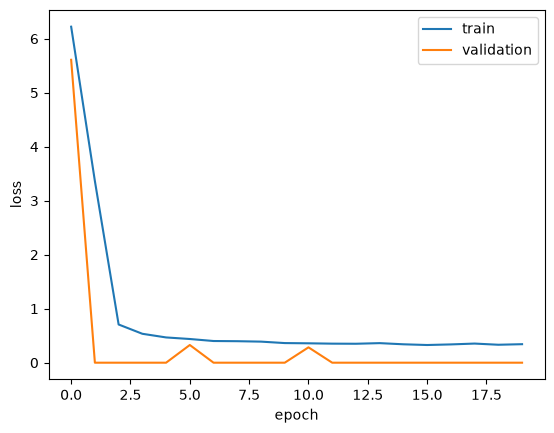

In [16]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 3. Score it again

In [17]:
finetuned = models.CellposeModel(gpu=True, pretrained_model=model_path)

masks_after, _, _ = finetuned.eval(test_images, batch_size=8)

pd.DataFrame({
    'pretrained': score(masks_before),
    'fine-tuned': score(masks_after),
}).round(2)

2026-09-17 23:29:11,816 [core INFO] ** TORCH CUDA version installed and working. **
2026-09-17 23:29:11,817 [core INFO] >>>> using GPU (CUDA)
2026-09-17 23:29:13,265 [models INFO] >>>> loading model cellpose_output/models/nuclei_from_phalloidin
2026-09-17 23:29:22,703 [utils INFO] 100%|##########| 20/20 [00:09<00:00,  2.21it/s]


,pretrained,fine-tuned
TP,2.300000,94.099998
FP,103.000000,3.800000
FN,95.199997,3.400000
precision,0.020000,0.920000
recall,0.020000,0.920000
F1,0.020000,0.920000


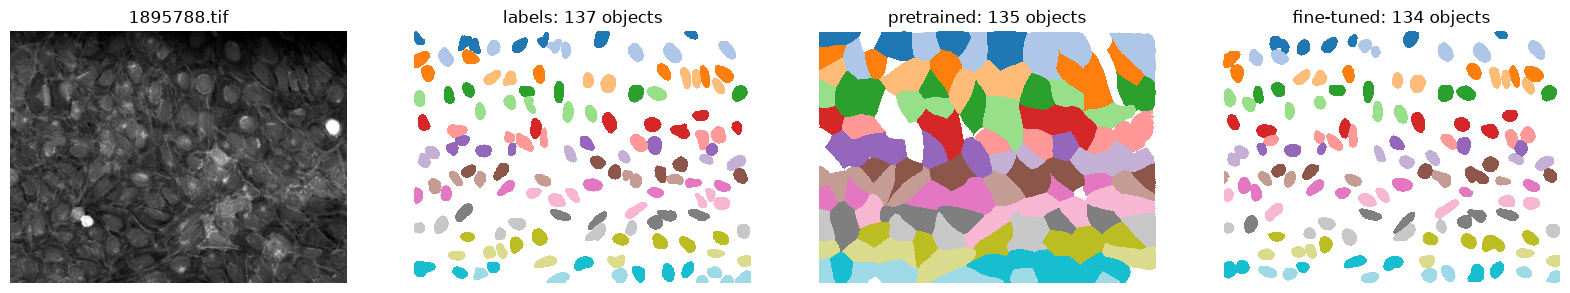

In [19]:
i = 0   # change this to look at another test image

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(test_images[i], cmap='gray',
               vmin=np.percentile(test_images[i], 1), vmax=np.percentile(test_images[i], 99.8))
axes[0].set_title(test_names[i])

for ax, lab, title in zip(axes[1:],
                          [test_labels[i], masks_before[i], masks_after[i]],
                          ['labels', 'pretrained', 'fine-tuned']):
    ax.imshow(np.ma.masked_equal(lab, 0), cmap='tab20', interpolation='nearest')
    ax.set_title(f'{title}: {lab.max()} objects')

for ax in axes:
    ax.axis('off')

The pretrained model was never asked to find nuclei in an actin image. The fine-tuned one has
seen our training images. Where does it still get it wrong?

## If you have time

- Try to train longer for `n_epochs=100`
- Fine-tune on 10 images instead of all (`train_images[:10]`, `train_labels[:10]`). This is
  the argument for fine-tuning: how far down can you go before the score drops?